# Chapter 9 (extra) — RRDE collection efficiency

The main Chapter 9 material treats the **rotating disk electrode** (RDE): one
electrode, one transport coordinate normal to the disk.  Here we go one step
beyond, to the **rotating ring–disk electrode** (RRDE), a *two-electrode*
geometry that is the workhorse of mechanistic electrochemistry.

A central disk of radius $r_1$ generates a species $R$ (for example $O + ne \to R$).
The rotation drives the solution radially outward across an insulating gap, and
a concentric **ring** electrode (inner radius $r_2$, outer radius $r_3$) held at
a potential that re-oxidises $R$ collects whatever survives the trip.  The
fraction collected is the **collection efficiency**

$$ N = \frac{-i_R}{i_D}, $$

(Bard & Faulkner, *Electrochemical Methods*, 2nd ed., eq. 9.4.15, p. 351).

The remarkable fact, established by Albery & Bruckenstein, is that $N$ depends
**only on the geometry** $(r_1, r_2, r_3)$, not on the rotation rate $\omega$,
the bulk concentration, the diffusion coefficient, or the number of electrons.
B&F (p. 351): *"$N$ … depends only on $r_1$, $r_2$, and $r_3$ and is independent
of $\omega$, $C_O^*$, $D_O$, $D_R$, etc."*

This notebook does two independent things and checks they agree:

1. **Closed form**: implement the Albery–Bruckenstein analytic $N(r_1,r_2,r_3)$
   (B&F eqs. 9.4.16/9.4.17).
2. **PDE march**: solve the steady ring convective–diffusion equation
   (B&F eq. 9.4.9) numerically, by marching *outward in $r$*, and integrate the
   ring wall flux to get $N$ from first principles.

**Validation anchor.** B&F state (p. 352): for $r_1 = 0.187$, $r_2 = 0.200$,
$r_3 = 0.332$ cm, $N = 0.555$: *"55.5% of the product generated at the disk is
collected at the ring."* Both routes must reproduce this number.

In [1]:
import os, sys
# Walk up to the repo root (the directory containing the ``serm`` package) so
# this notebook imports cleanly whether run from notebooks/ or notebooks/extras/.
_d = os.path.abspath('..')
while not os.path.isdir(os.path.join(_d, "serm")) and os.path.dirname(_d) != _d:
    _d = os.path.dirname(_d)
sys.path.insert(0, _d)
get_ipython().run_line_magic('matplotlib', 'inline')

import numpy as np
import matplotlib.pyplot as plt

from serm import rrde

# The B&F reference geometry (cm) and reference collection efficiency.
R1, R2, R3 = 0.187, 0.200, 0.332
N_REF = 0.555


In [2]:
from serm.sourcelinks import source_links
source_links(rrde)

## 1. The Albery–Bruckenstein closed form

The collection-efficiency problem can be solved analytically with Laplace
transforms and Airy functions (B&F cite Albery, Bruckenstein, Hitchman).  The
result is expressed through two geometry parameters

$$ \alpha = \left(\frac{r_2}{r_1}\right)^3 - 1, \qquad
   \beta = \frac{r_3^3 - r_2^3}{r_1^3} \quad\text{(B\&F eq. 9.4.8)}, $$

and an auxiliary function (B&F eq. 9.4.17, p. 352)

$$ F(\theta) = \frac{\sqrt 3}{4\pi}\,
   \ln\!\left[\frac{(1+\theta^{1/3})^3}{1+\theta}\right]
   + \frac{3}{2\pi}\arctan\!\left(\frac{2\theta^{1/3}-1}{\sqrt 3}\right)
   + \frac14 . $$

The collection efficiency is then (B&F eq. 9.4.16)

$$ N = 1 - F(\alpha/\beta) + \beta^{2/3}\,[1 - F(\alpha)]
       - (1+\alpha+\beta)^{2/3}\,
         \bigl\{1 - F[(\alpha/\beta)(1+\alpha+\beta)]\bigr\}. $$

These are implemented in `serm.rrde.F_albery` and
`serm.rrde.collection_efficiency_closed_form`.

In [3]:
N_closed = rrde.collection_efficiency_closed_form(R1, R2, R3)
print(f"Closed-form N  = {N_closed:.5f}")
print(f"B&F anchor     = {N_REF}")
print(f"difference     = {abs(N_closed - N_REF):.2e}")

assert abs(N_closed - N_REF) < 5e-4, "closed form must reproduce B&F N = 0.555"


Closed-form N  = 0.55504
B&F anchor     = 0.555
difference     = 3.51e-05


### The auxiliary function $F(\theta)$

$F(\theta)$ is monotone and maps $[0,\infty) \to$ roughly $[0,1]$.  It is the
building block of the analytic $N$.  We plot it for reference (regenerated in
matplotlib, not copied from B&F).

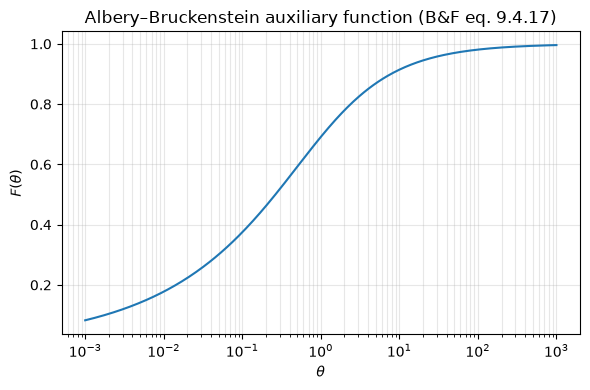

In [4]:
theta = np.logspace(-3, 3, 400)
fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogx(theta, rrde.F_albery(theta), color="C0")
ax.set_xlabel(r"$\theta$")
ax.set_ylabel(r"$F(\theta)$")
ax.set_title("Albery–Bruckenstein auxiliary function (B&F eq. 9.4.17)")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()


## 2. The PDE: steady ring convective–diffusion

For an *independent* check we solve the transport equation directly.  In the
thin diffusion layer the radial velocity grows linearly with the wall distance
$y$, and after dropping radial diffusion the steady-state equation for the
collected species $R$ is (B&F eq. 9.4.9, p. 351):

$$ r\,\frac{\partial C_R}{\partial r}
   - y\,\frac{\partial C_R}{\partial y}
   = \frac{D_R}{B'}\,\frac{1}{y}\,\frac{\partial^2 C_R}{\partial y^2}, $$

where $B' = 0.51\,\omega^{3/2}\nu^{-1/2}$ is the Cochran wall-shear coefficient.

Because there is **no** radial-diffusion term, the equation is *parabolic in $r$*:
information only propagates outward.  This is exactly the structure that lets us
**march in $r$** (like marching in time) instead of solving a full 2-D
boundary-value problem.

**Wall boundary conditions** ($y = 0$), which switch with the radial region:

| region | range | condition | B&F eq. |
|---|---|---|---|
| disk  | $0 \le r < r_1$   | $(\partial C_R/\partial y)_{0} = -i_D/(\pi r_1^2 nF D_R)$ (imposed flux) | 9.4.11 |
| gap   | $r_1 \le r < r_2$ | $(\partial C_R/\partial y)_{0} = 0$ (insulator, no flux) | 9.4.12 |
| ring  | $r_2 \le r < r_3$ | $C_R(0) = 0$ (limiting collection) | 9.4.13 |

The ring current is the integrated wall flux over the ring (B&F eq. 9.4.14):

$$ i_R = nF D_R\, 2\pi \int_{r_2}^{r_3}
        \Bigl(\frac{\partial C_R}{\partial y}\Bigr)_{0} r\,dr,
   \qquad N = \frac{-i_R}{i_D}. $$

### Why $N$ is invariant, and how we exploit it

The equation is **linear and homogeneous** in $C_R$, so multiplying the disk
flux by any constant (that is, changing $i_D$, the bulk concentration, or $n$)
multiplies both $i_R$ and $i_D$ equally; $N$ is untouched.

The only physical parameter is the group $D_R/B'$, which sets a length scale in
$y$.  Scaling $y$ by $(D_R/B')^{1/3}$ makes the right-hand-side coefficient
exactly $1$, eliminating $\omega$ and $D_R$ from the problem.  Scaling $r$ by
$r_1$ leaves only the **ratios** $r_2/r_1$, $r_3/r_1$.  By construction the
PDE march therefore sees nothing but geometry.

This means the $\omega$ / $D$ / $C^*$ invariance is a **structural
nondimensionalisation sanity check that cannot fail** (those parameters never
enter the solver's signature) rather than a falsifiable validation.  The genuine
independent cross-check is the geometry sweep below (closed form versus PDE march
across several geometries), which *could* disagree but does not.

Numerically we march in $s = \ln r$ (so $r\,\partial_r = \partial_s$),
treating each step implicitly in $y$ (a tridiagonal solve) for unconditional
stability, on a **wall-graded** $y$-grid that resolves the thin boundary layer.
The advective $+y\,\partial_y$ term is upwinded to keep the implicit operator an
M-matrix.  All of this lives in `serm.rrde.collection_efficiency_pde`.

In [5]:
res = rrde.collection_efficiency_pde(R1, R2, R3)
N_pde = res.N
print(f"PDE-march N    = {N_pde:.5f}")
print(f"B&F anchor     = {N_REF}")
print(f"closed form    = {N_closed:.5f}")
print(f"|PDE - anchor| = {abs(N_pde - N_REF):.2e}")
print(f"|PDE - closed| = {abs(N_pde - N_closed):.2e}")

# Independent PDE march vs the analytic anchor.  The march is a FIRST-ORDER
# upwind scheme that is NOT grid-converged (see the convergence cell below):
# at the default grid it lands ~1% from the anchor.  We keep the loose 3e-3
# assert at the default grid; do not read it as a tight precision claim.
assert abs(N_pde - N_REF) < 3e-3,  "PDE march must reproduce B&F N = 0.555"
assert abs(N_pde - N_closed) < 3e-3, "PDE march must agree with the closed form"


PDE-march N    = 0.55440
B&F anchor     = 0.555
closed form    = 0.55504
|PDE - anchor| = 6.00e-04
|PDE - closed| = 6.35e-04


### Grid convergence of the PDE march

The march uses a **first-order upwind** advection term, so it is only
first-order accurate and *not* grid-converged at the default resolution. As we
refine $n_r$, $N$ drifts **monotonically upward**, passing through the anchor
$N\approx0.555$ rather than landing on it exactly. The default $n_r=12000$
result ($0.5544$) is therefore good to about **1%**, and its closeness to
$0.555$ is partly fortuitous: refining further moves it past the anchor.

In [6]:
# First-order upwind march -> monotone drift, ~1% accuracy (NOT a tight bound).
print(f"{'nr':>8s}{'N_pde':>10s}{'|N - anchor|':>14s}")
for nr in [3000, 6000, 12000, 24000]:
    Nnr = rrde.collection_efficiency_pde(R1, R2, R3, nr=nr).N
    print(f"{nr:>8d}{Nnr:>10.4f}{abs(Nnr - N_REF):>14.4f}")
print(f"\nclosed form / B&F anchor = {N_REF}")
print("The march is first-order (upwind); N drifts monotonically through ~0.555")
print("as the grid refines, so the default landing at 0.5544 is good to ~1% and")
print("partly fortuitous -- not a sub-1e-3 precision result.")

      nr     N_pde  |N - anchor|


    3000    0.5439        0.0111


    6000    0.5513        0.0037


   12000    0.5544        0.0006


   24000    0.5560        0.0010

closed form / B&F anchor = 0.555
The march is first-order (upwind); N drifts monotonically through ~0.555
as the grid refines, so the default landing at 0.5544 is good to ~1% and
partly fortuitous -- not a sub-1e-3 precision result.


### The concentration field

Marching outward we accumulate the full field $C_R(r, y)$.  Below the disk it
builds up (constant generation flux); across the insulating gap it coasts (no
wall flux) while convection carries the plume outward and diffusion spreads it;
over the ring it is pinned to zero at the wall, and the resulting steep wall
gradient *is* the collected current.

This is the quantitative version of B&F Figure 9.4.3, regenerated here from our
own solution rather than copied.

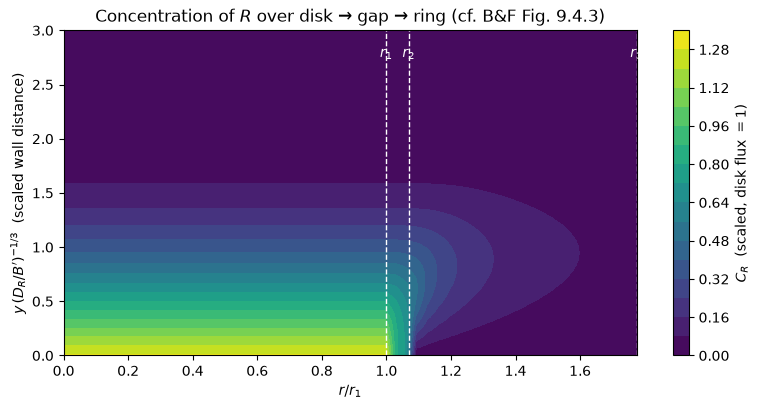

In [7]:
r = res.r
y = res.y
C = res.C
R1s, R2s, R3s = 1.0, R2 / R1, R3 / R1   # scaled radii (r1 -> 1)

# Restrict the axial window to the boundary layer for a readable contour plot.
ny_plot = np.searchsorted(y, 3.0)
# Sub-sample radial stations for speed.
ri = np.linspace(0, len(r) - 1, 400).astype(int)
Rg, Yg = np.meshgrid(r[ri], y[:ny_plot], indexing="ij")
Cg = C[np.ix_(ri, np.arange(ny_plot))]

fig, ax = plt.subplots(figsize=(8, 4.2))
cf = ax.contourf(Rg, Yg, Cg, levels=20, cmap="viridis")
cb = fig.colorbar(cf, ax=ax)
cb.set_label(r"$C_R$  (scaled, disk flux $=1$)")
for xc, lab in [(R1s, r"$r_1$"), (R2s, r"$r_2$"), (R3s, r"$r_3$")]:
    ax.axvline(xc, color="w", ls="--", lw=1)
    ax.text(xc, 2.85, lab, color="w", ha="center", va="top")
# Mark the three wall regions along the bottom axis.
ax.axhspan(-0.05, 0.0, xmin=0, xmax=1, color="none")
ax.set_xlim(0, R3s)
ax.set_ylim(0, 3.0)
ax.set_xlabel(r"$r / r_1$")
ax.set_ylabel(r"$y\,(D_R/B')^{-1/3}$  (scaled wall distance)")
ax.set_title("Concentration of $R$ over disk → gap → ring (cf. B&F Fig. 9.4.3)")
plt.tight_layout()
plt.show()


### Wall flux along the radius

The wall gradient $(\partial C_R/\partial y)_0$ tells the whole story in one
curve: it is held at $-1$ over the disk (imposed generation), drops to $0$ over
the insulating gap, and becomes **positive** over the ring as $R$ is consumed
($C_R = 0$ at the wall, rising into the plume above).  The shaded area under the
ring portion, weighted by $2\pi r$, is the collected current.

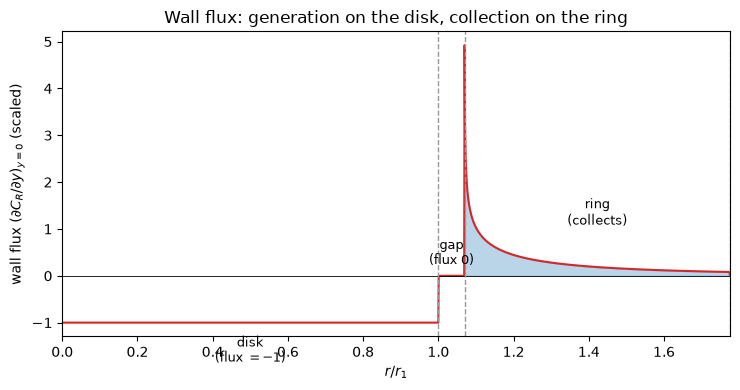

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(r, res.wall_flux, color="C3", lw=1.5)
ax.axhline(0, color="k", lw=0.6)
for xc, lab in [(R1s, r"$r_1$"), (R2s, r"$r_2$"), (R3s, r"$r_3$")]:
    ax.axvline(xc, color="0.6", ls="--", lw=1)
ax.text((0 + R1s) / 2, -1.25, "disk\n(flux $=-1$)", ha="center", va="top", fontsize=9)
ax.text((R1s + R2s) / 2, 0.15, "gap\n(flux $0$)", ha="center", va="bottom", fontsize=9)
ax.text((R2s + R3s) / 2, 1.0, "ring\n(collects)", ha="center", va="bottom", fontsize=9)
# Shade the collected-current region.
ring_mask = (r >= R2s) & (r <= R3s)
ax.fill_between(r[ring_mask], 0, res.wall_flux[ring_mask], color="C0", alpha=0.3)
ax.set_xlim(0, R3s)
ax.set_xlabel(r"$r / r_1$")
ax.set_ylabel(r"wall flux $(\partial C_R/\partial y)_{y=0}$ (scaled)")
ax.set_title("Wall flux: generation on the disk, collection on the ring")
plt.tight_layout()
plt.show()


## 3. Cross-checks

### The headline independent cross-check: closed form vs PDE across geometries

The real, **falsifiable** validation is that two completely unrelated routes,
the Albery–Bruckenstein closed form and the parabolic PDE march, agree on $N$
across several different geometries (below, to $\lesssim 5\times10^{-3}$). This
*could* fail if either method were wrong; it does not.

### Structural sanity checks (cannot fail by construction)

B&F also state that $N$ is independent of $\omega$, concentration, and $D$. In
our nondimensionalised formulation those parameters **never enter the solver**,
so this invariance is exact *by construction*: a structural sanity check on the
scaling, not a falsifiable test. Likewise, scaling all three radii by a common
factor leaves $N$ fixed because the solver sees only the ratios $r_2/r_1$,
$r_3/r_1$. We also check the disk-off ring/disk current ratio
$i_R/i_D = \beta^{2/3}$ (B&F eq. 9.4.8) and the shielding factor (eq. 9.4.20).

In [9]:
# HEADLINE CROSS-CHECK: closed form vs independent PDE march across geometries.
# This is the falsifiable one -- two unrelated methods that could disagree.
print("Closed form vs independent PDE march:")
print(f"  {'(r1,r2,r3)':<24}{'closed':>9}{'pde':>9}{'|diff|':>9}")
for g in [(0.187, 0.200, 0.332),
          (0.187, 0.200, 0.250),
          (0.200, 0.220, 0.400),
          (0.100, 0.110, 0.200)]:
    Nc = rrde.collection_efficiency_closed_form(*g)
    Np = rrde.collection_efficiency_pde(*g).N
    print(f"  {str(g):<24}{Nc:>9.4f}{Np:>9.4f}{abs(Nc - Np):>9.4f}")
    assert abs(Nc - Np) < 6e-3


Closed form vs independent PDE march:
  (r1,r2,r3)                 closed      pde   |diff|


  (0.187, 0.2, 0.332)        0.5550   0.5544   0.0006


  (0.187, 0.2, 0.25)         0.3709   0.3662   0.0047


  (0.2, 0.22, 0.4)           0.5909   0.5905   0.0004


  (0.1, 0.11, 0.2)           0.5909   0.5905   0.0004


In [10]:
# STRUCTURAL SANITY CHECK (cannot fail by construction): radius-ratio scaling.
# Multiply every radius by k -> N must not move (solver sees only ratios).
print("Geometric scale invariance (N depends only on radius ratios):")
N_base = rrde.collection_efficiency_closed_form(R1, R2, R3)
for k in [0.5, 1.0, 2.0, 10.0]:
    Nk = rrde.collection_efficiency_closed_form(k * R1, k * R2, k * R3)
    print(f"  k={k:>4}:  N = {Nk:.6f}   (Δ from base = {abs(Nk - N_base):.1e})")
    assert abs(Nk - N_base) < 1e-12

# STRUCTURAL SANITY CHECK (cannot fail): the PDE solver carries no omega / D /
# concentration argument at all -- its signature is purely geometric, so the
# omega/D/C* invariance is exact by construction (this confirms inspect.signature,
# NOT a numerical solve).
import inspect
params = list(inspect.signature(rrde.collection_efficiency_pde).parameters)
print("\nPDE solver geometric+numeric parameters only:", params[:3], "(+ grid controls)")
assert not any(p in params for p in ("omega", "D", "conc", "C_bulk", "n")), \
    "solver must not depend on omega / D / concentration"


Geometric scale invariance (N depends only on radius ratios):
  k= 0.5:  N = 0.555035   (Δ from base = 0.0e+00)
  k= 1.0:  N = 0.555035   (Δ from base = 0.0e+00)
  k= 2.0:  N = 0.555035   (Δ from base = 0.0e+00)
  k=10.0:  N = 0.555035   (Δ from base = 4.4e-16)

PDE solver geometric+numeric parameters only: ['r1', 'r2', 'r3'] (+ grid controls)


In [11]:
# (3) Ring/disk current ratio (eq. 9.4.8) and shielding factor (eq. 9.4.20).
ratio = rrde.ring_disk_current_ratio(R1, R2, R3)        # i_R/i_D = beta^(2/3), disk off
shield = rrde.shielding_factor(R1, R2, R3)              # 1 - N beta^(-2/3)
beta = (R3**3 - R2**3) / R1**3
print(f"beta                      = {beta:.5f}")
print(f"i_R/i_D = beta^(2/3)      = {ratio:.5f}   (B&F eq. 9.4.8, disk inactive)")
print(f"shielding factor 1-Nβ^-2/3 = {shield:.5f}   (B&F eq. 9.4.20)")
assert abs(ratio - beta**(2/3)) < 1e-12
# Shielding factor must lie in (0,1): a live disk always *reduces* the ring current.
assert 0.0 < shield < 1.0


beta                      = 4.37276
i_R/i_D = beta^(2/3)      = 2.67406   (B&F eq. 9.4.8, disk inactive)
shielding factor 1-Nβ^-2/3 = 0.79244   (B&F eq. 9.4.20)


## 4. How $N$ depends on geometry

Finally we map the collection efficiency across geometry, reproducing B&F's
qualitative statement (p. 352): *"$N$ becomes larger as the gap thickness
$(r_2 - r_1)$ decreases and as the ring size $(r_3 - r_2)$ increases."*

We sweep the gap and ring widths (in units of $r_1 = 1$) using the fast closed
form.

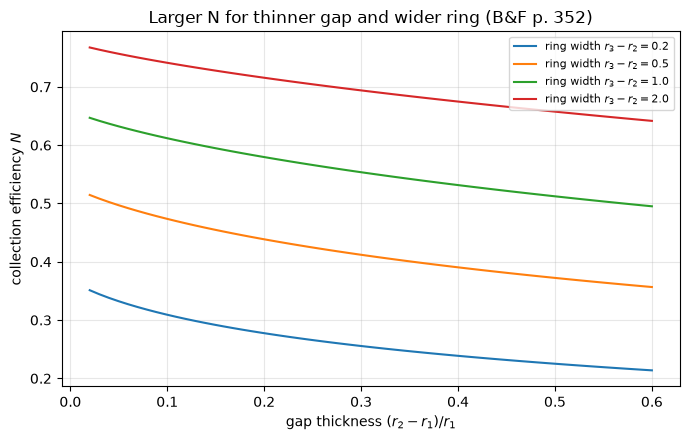

In [12]:
r1 = 1.0
gap_widths = np.linspace(0.02, 0.6, 60)     # r2 - r1
ring_widths = np.array([0.2, 0.5, 1.0, 2.0])  # r3 - r2

fig, ax = plt.subplots(figsize=(7, 4.5))
for rw in ring_widths:
    Nvals = []
    for gw in gap_widths:
        r2 = r1 + gw
        r3 = r2 + rw
        Nvals.append(rrde.collection_efficiency_closed_form(r1, r2, r3))
    ax.plot(gap_widths, Nvals, label=fr"ring width $r_3-r_2={rw}$")
ax.set_xlabel(r"gap thickness $(r_2 - r_1)/r_1$")
ax.set_ylabel(r"collection efficiency $N$")
ax.set_title("Larger N for thinner gap and wider ring (B&F p. 352)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Summary

* **Closed form** (Albery–Bruckenstein, B&F eqs. 9.4.16/9.4.17) reproduces the
  B&F anchor $N = 0.555$ for $(r_1,r_2,r_3) = (0.187, 0.200, 0.332)$ cm to
  $\sim 5\times10^{-5}$.
* **Independent PDE march** of the parabolic ring convective–diffusion equation
  (B&F eq. 9.4.9), with region-switching wall BCs and integrated ring flux,
  reproduces the same number to **$\sim 1\%$** at the default grid. The march
  is a first-order upwind scheme and is *not* grid-converged: $N$ drifts
  $0.5439\to0.5513\to0.5544\to0.5560$ as $n_r$ goes $3000\to24000$, passing
  through the anchor, so the default $0.5544$ is good to about 1% and partly
  fortuitous. The agreement of two unrelated methods at the ~1% level is still a
  genuine cross-check.
* **Invariance** of $N$ with respect to $\omega$, concentration, and $D$ is
  exact *by construction* (those parameters never enter the solver): a
  structural sanity check, not a falsifiable test. Scale invariance in the radii
  holds to machine precision for the same reason. The **headline** independent
  cross-check is instead the closed-form-vs-PDE geometry sweep, which could
  disagree but agrees to $\lesssim 5\times10^{-3}$.
* The geometric trends ($N$ up for thinner gap / wider ring) and the disk-off
  ring/disk ratio $\beta^{2/3}$ match B&F.

<!-- nav-footer -->

---

[← Chapter 14 — Rotating disk electrode voltammetry](../14_rotating_disk_electrode.ipynb)

[Contents (README)](../../README.md)